In [107]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


EDA visualizations: yield trends over time, bryophyte species richness and identification counts by year, correlation matrix across all variables, and species richness per 100 minutes versus yield scatter.

In [108]:

DATA_DIR = "preprocessing_results"
DATA_FULL_FILE = "EDA_merged_ABC_2008_2010_2019.csv"
DATA_WHEAT_FILE = "wheat_yield_full_historical.csv"

df = pd.read_csv(os.path.join(DATA_DIR, DATA_FULL_FILE))

df = df.sort_values("Year").reset_index(drop=True)

wheat_full = pd.read_csv(os.path.join(DATA_DIR, DATA_WHEAT_FILE)) # used for yield trend plot for better context
wheat_full = wheat_full.sort_values("Year").reset_index(drop=True)


### plot_time_series()

Display line plots of the given data.

In [109]:
def plot_time_series(df, columns, title):
    plt.figure()

    for col in columns:
        plt.plot(df["Year"], df[col], marker="o", label=col)

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.show()

The historical wheat yield series shows a long term upward trend across the full 1908 to 2021 period driven by agricultural technology improvements, with the modeling window of 2008 to 2019 capturing a relatively stable high yield plateau suitable for isolating year to year climate and ecological variation. 

Bryophyte richness per 100 minutes shows a U shaped pattern across the window with a notable drop in 2011 and a strong rise toward 2019.

Climate variables are broadly stable across the window with the exception of precipitation, which shows meaningful year to year swings between roughly 200 and 425mm, while frost free days remain nearly constant across all years, consistent with its limited contribution to model fit.

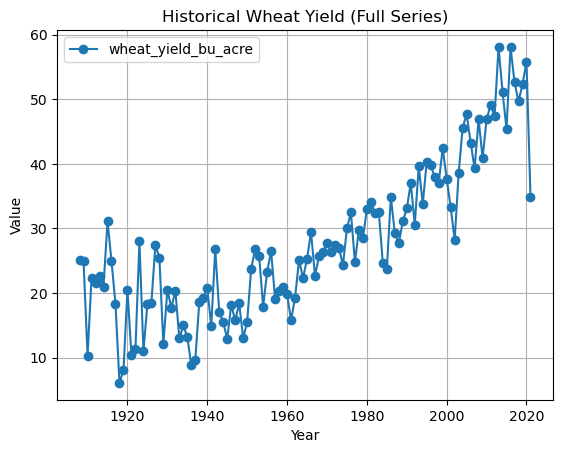

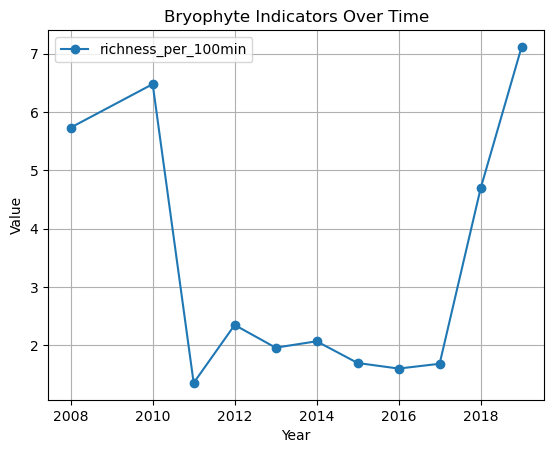

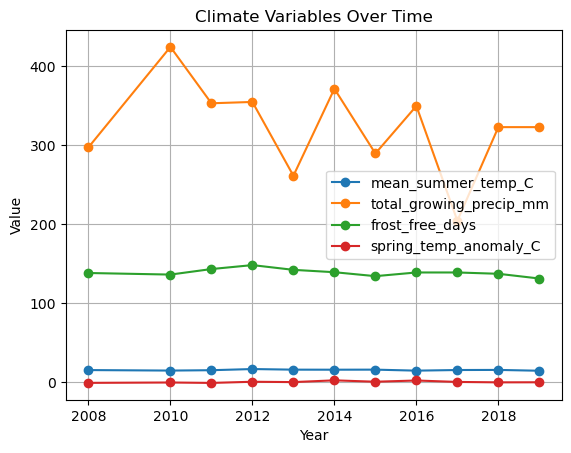

In [ ]:
# Used to reveal interactions

plot_time_series(wheat_full, ["wheat_yield_bu_acre"], "Historical Wheat Yield (Full Series)")

plot_time_series(df, ["richness_per_100min"], "Bryophyte Indicators Over Time")

plot_time_series(
    df,
        [
            "mean_summer_temp_C",
            "total_growing_precip_mm",
            "frost_free_days",
            "spring_temp_anomaly_C"
        ],
        "Climate Variables Over Time"
)


### plot_correlation_matrix()

Shows the correlation matrix as a heat map, blue for negative correlations, yellow for positive.

It's simple so it can be used pretty universally.

In [118]:
def plot_correlation_matrix(df, cols=None):
    if cols is not None:
        data = df[cols]
    else:
        data = df

    corr = data.corr(numeric_only=True)

    plt.figure()
    plt.imshow(corr)
    plt.colorbar()

    labels = corr.columns
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right", rotation_mode="anchor")
    plt.yticks(range(len(labels)), labels)

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

The modeling correlation matrix (Image 1) shows that spring_temp_anomaly_C has the strongest positive correlation with wheat yield while richness_per_100min, mean_summer_temp_C, and total_growing_precip_mm are all negatively correlated with yield, consistent with the model coefficients. 

The full EDA matrix (Image 2) reveals that many of the raw bryophyte count variables such as species_richness, total_identifications, and ids_per_site are strongly intercorrelated with each other and with n_sites_sampled, which reflects sampling effort rather than ecology and justifies the decision to use richness_per_100min as the effort corrected summary metric instead. 

Year shows a moderate positive correlation with wheat yield, echoing the long term upward trend visible in the time series plot, and frost_free_days clusters tightly with mean_summer_temp_C suggesting they capture overlapping aspects of seasonal warmth, which is consistent with frost free days contributing little additional explanatory power in the models.

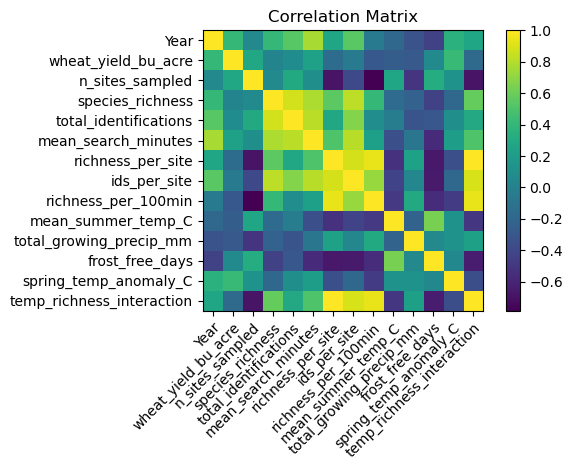

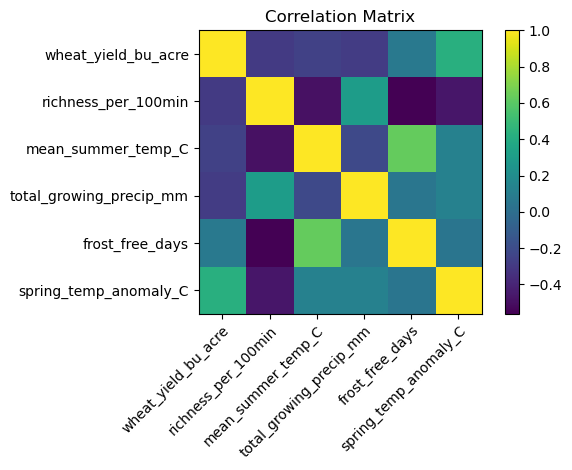

In [119]:

plot_correlation_matrix(df)

plot_correlation_matrix(
    df,
    [
        "wheat_yield_bu_acre",
        "richness_per_100min",
        "mean_summer_temp_C",
        "total_growing_precip_mm",
        "frost_free_days",
        "spring_temp_anomaly_C"
    ]
)

### scatter_set()

Displays scatter set for given input.

It's simple so it can be used pretty universally.

In [113]:
def scatter_set(df, x_cols, y_col):
    for x_col in x_cols:
        x = df[x_col]
        y = df[y_col]

        plt.figure()
        plt.scatter(x, y)

        if len(x) > 1:
            m, b = np.polyfit(x, y, 1)
            plt.plot(x, m * x + b)

        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{x_col} vs {y_col}")

        plt.grid()
        plt.show()

The scatter plots reveal a negative relationship between richness_per_100min and wheat_yield_bu. This could be because bryophytes tend to thrive in moist environments, but wheat growth does not. 

Mean_summer_temp_C, and total_growing_precip_mm, have negative correlations with wheat_yield_bu. This could be because excess heat and precipitate can be damaging to wheat. Although it is also likely that the 11 samples is not reflecting the relationship correctly.

Spring_temp_anomally_C and frost_free_days both have positive correlations. This actually does make sense, because the more frost free days the more days available to grow wheat. Similarly, spring temperatures may be more favourable for wheat growth than winter and summer. 

Spring temperature has the strongest correlations.

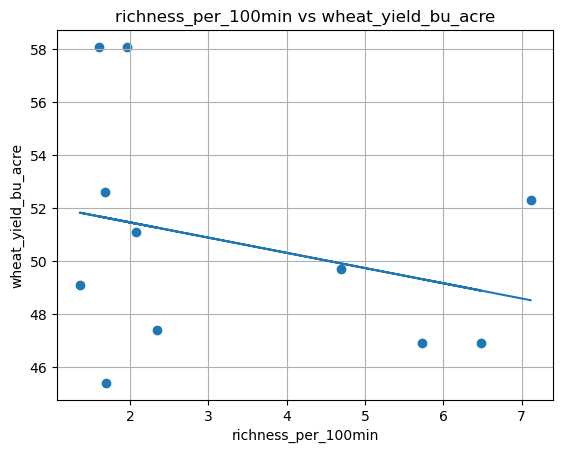

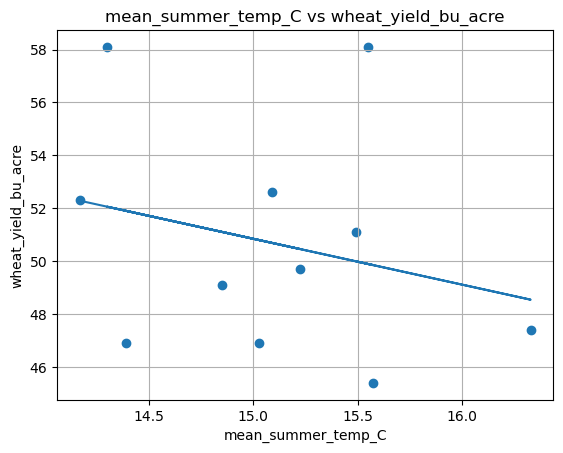

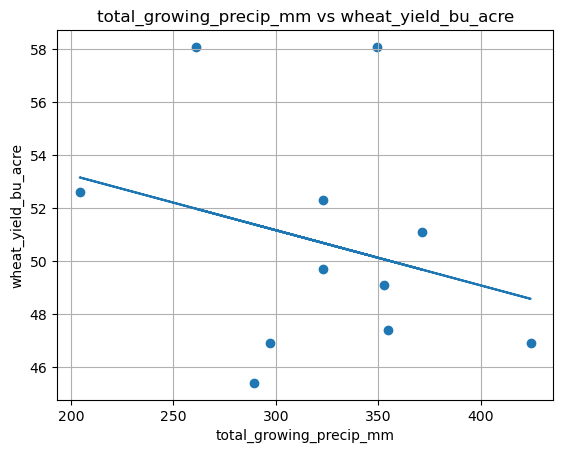

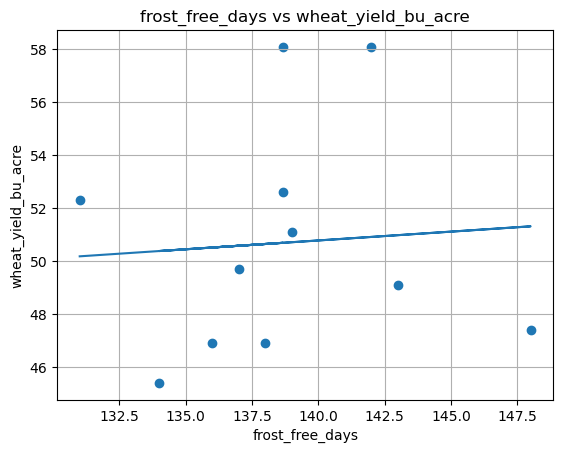

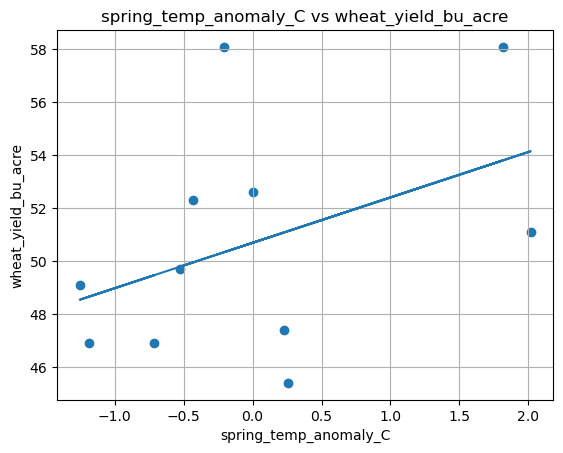

In [114]:

scatter_set(
    df,
    ["richness_per_100min"],
    "wheat_yield_bu_acre"
)

scatter_set(
    df,
    [
        "mean_summer_temp_C",
        "total_growing_precip_mm",
        "frost_free_days",
        "spring_temp_anomaly_C"
    ],
    "wheat_yield_bu_acre"
)



### Run_modeling_diagnostics()

Checks multicollinearity using variance inflation factor (VIF), and influences using cook's distance.

Displays the results in an easy to interperate manner


In [115]:

def run_modeling_diagnostics(df, feature_cols, target_col):
    data = df[feature_cols + [target_col]].dropna()
    X = data[feature_cols]
    y = data[target_col]
    X_const = sm.add_constant(X)
    
    # Multicollinearity Check
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]
    
    # Influence Check (Cook's Distance)
    model = sm.OLS(y, X_const).fit()
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    
    print(f"\n{target_col}")
    print("\nVIF Scores:")
    print(vif_df)
    
    print("\nCook's Distance (by row index):")
    for i, d in enumerate(cooks_d):
        label = "!!!" if d > (4/len(X)) else ""
        print(f"Index {i}: {d:.4f} {label}")

    print("\nModel Coefficients:")
    print(model.params[1:])
    return model

All three models have VIF scores under 2, well below the conventional threshold of 5, confirming no multicollinearity issues. Coefficients can be interpreted without concerns over variance inflation.

In Model A the most influential point is Index 4 (Cook's D = 0.3372), corresponding to 2014, followed by Index 7 (0.2750) and Index 8 (0.1504). Model B shows a similar pattern with Index 4 remaining the dominant leverage point. No Cook's Distance in any model exceeds 1, so no single observation dominates the regression.

Across Models A and B, spring_temp_anomaly_C is the only positive coefficient, suggesting warmer than average springs associate with higher wheat yield. mean_summer_temp_C and total_growing_precip_mm are both negative. richness_per_100min is negative in both Models B and C. These directions are consistent with the relationships observed in the scatterplots.

In [116]:
model_b_features = [
        "richness_per_100min", 
        "mean_summer_temp_C",
        "spring_temp_anomaly_C", 
        "total_growing_precip_mm",
]

model_a_features = [
    "mean_summer_temp_C", 
    "total_growing_precip_mm", 
    "spring_temp_anomaly_C"
]

model_c_features = [
        "richness_per_100min",  
]
    
run_modeling_diagnostics(df, model_a_features, "wheat_yield_bu_acre")
run_modeling_diagnostics(df, model_b_features, "wheat_yield_bu_acre")
run_modeling_diagnostics(df, model_c_features, "wheat_yield_bu_acre")


wheat_yield_bu_acre

VIF Scores:
                   feature       VIF
0       mean_summer_temp_C  1.077451
1  total_growing_precip_mm  1.076134
2    spring_temp_anomaly_C  1.042059

Cook's Distance (by row index):
Index 0: 0.0322 
Index 1: 0.0308 
Index 2: 0.0178 
Index 3: 0.0287 
Index 4: 0.3372 
Index 5: 0.0552 
Index 6: 0.1301 
Index 7: 0.2750 
Index 8: 0.1504 
Index 9: 0.0007 
Index 10: 0.0001 

Model Coefficients:
mean_summer_temp_C        -2.837859
total_growing_precip_mm   -0.032416
spring_temp_anomaly_C      2.155278
dtype: float64

wheat_yield_bu_acre

VIF Scores:
                   feature       VIF
0      richness_per_100min  1.907900
1       mean_summer_temp_C  1.339175
2    spring_temp_anomaly_C  1.433090
3  total_growing_precip_mm  1.222954

Cook's Distance (by row index):
Index 0: 0.0205 
Index 1: 0.0133 
Index 2: 0.0214 
Index 3: 0.0346 
Index 4: 0.2408 
Index 5: 0.0264 
Index 6: 0.1074 
Index 7: 0.1685 
Index 8: 0.1366 
Index 9: 0.0028 
Index 10: 0.0200 

Model Coeffi

Model A uses:
* Mean Summer Temperature
* Total Growing Season Precipitation
* Spring Temperature Anomaly  
 
 This is because the correlation matrix and VIF diagnostics proved these are the most robust, non-redundant climate drivers, specifically highlighting the positive impact of warm springs versus the negative impact of summer heat stress. 
 
Model B uses:
* Mean Summer Temperature
* Total Growing Season Precipitation
* Spring Temperature Anomaly  
* Richness per 100 minutes  

This is because exploratory diagnostics showed that adding this biological indicator increases the model explanatory power and provides a unique ground level signal that is not captured by meteorological data alone. 

Model C uses only Richness Per 100 minutes because it serves as a pure biological proxy to test the standalone relationship between biodiversity and yield, and it was chosen over total identifications to prioritize ecological diversity as a more stable indicator of microclimate conditions. Together, these models allow for a clear comparison between traditional climate modeling and integrated biological forecasting.